In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

In [2]:
# Ensure the project root is in the Python path for module imports
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
from algs.cd_poly import CDPolynomial

In [5]:
z = np.load('data/coeffs_dct.npy', 'r')

In [6]:
poly = PolynomialFeatures(3).fit_transform(z)
poly_std = poly / np.sqrt(len(z))

In [7]:
moments = (poly_std.T @ poly_std)

In [8]:
moments.shape

(364, 364)

In [17]:
print(f'{np.linalg.cond(moments):e}')

1.250289e+15


In [9]:
from matplotlib.colors import SymLogNorm

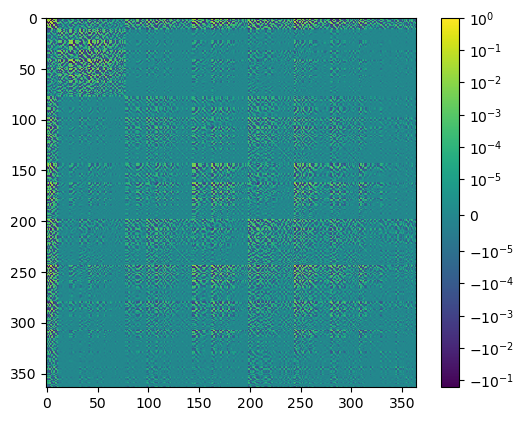

In [10]:
plt.imshow(moments, norm=SymLogNorm(linthresh=1e-5))
plt.colorbar()

Text(0.5, 0, 'log of abs of moments')

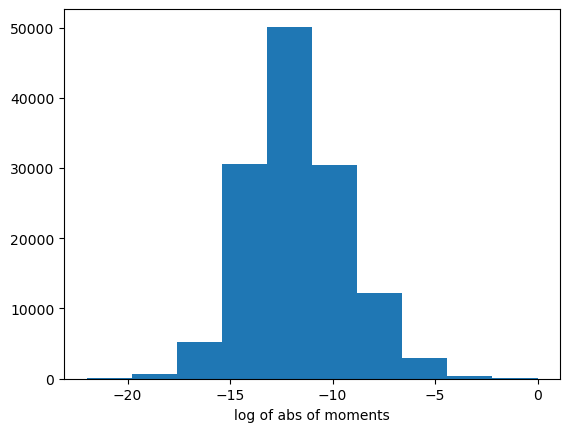

In [11]:
plt.hist(np.log(np.abs(moments.flatten())))
plt.xlabel('log of abs of moments')

In [12]:
U, S, Vh = np.linalg.svd(poly_std)

In [13]:
U.shape, S.shape, Vh.shape

((10000, 10000), (364,), (364, 364))

In [14]:
Vh.shape

(364, 364)

In [15]:
np.sort(S **2)[::-1]

array([1.25830945e+00, 7.68786974e-01, 2.79952392e-01, 1.79126498e-01,
       1.27049311e-01, 9.97344138e-02, 4.95339035e-02, 3.89786155e-02,
       3.20739476e-02, 2.43748343e-02, 2.23313196e-02, 1.74938268e-02,
       1.47893307e-02, 1.37920006e-02, 1.31842889e-02, 1.04864387e-02,
       7.72363930e-03, 5.84677326e-03, 4.90950746e-03, 4.43378793e-03,
       3.74899503e-03, 3.36153062e-03, 3.13977470e-03, 2.88705664e-03,
       2.76790881e-03, 1.97212553e-03, 1.86456828e-03, 1.62814381e-03,
       1.52943962e-03, 1.28730561e-03, 1.25004792e-03, 1.07777585e-03,
       9.20832435e-04, 7.56643151e-04, 7.48200094e-04, 7.09678217e-04,
       6.90034108e-04, 6.14189388e-04, 5.97838911e-04, 5.68621391e-04,
       4.87572899e-04, 4.41831280e-04, 4.03800206e-04, 3.86600210e-04,
       3.71143335e-04, 3.47228007e-04, 3.37465774e-04, 3.08829809e-04,
       2.83060278e-04, 2.81019841e-04, 2.44020044e-04, 2.18490085e-04,
       2.12172356e-04, 1.86949231e-04, 1.81366566e-04, 1.69305822e-04,
      

Text(0.5, 1.0, 'Eigenvalues of moment matrix')

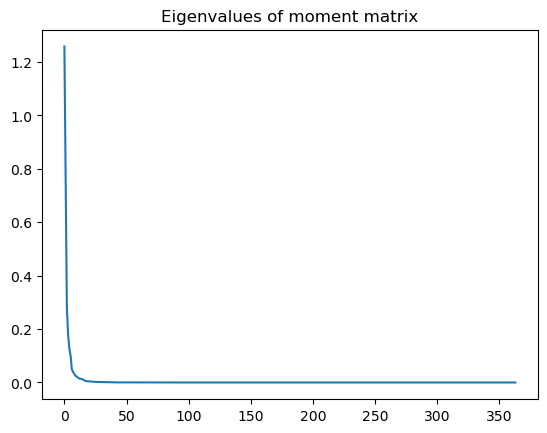

In [30]:
plt.plot(S ** 2)
plt.title('Eigenvalues of moment matrix')

In [14]:
rec_moments = Vh.T @ np.diag(S ** 2) @ Vh

In [15]:
np.allclose(moments, rec_moments)

True

In [129]:
Vh.shape

(364, 364)